# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name: Suneel Kumar

**Student ID: 023-24-0527

**Section: B

**GitHub: (https://github.com/WadhwaniSuneel/ML1.git)

**Kaggle:** https://www.kaggle.com/datasets/suneelwadhwani/churn-prediction-through-random-forest/data
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [29]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [30]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df=pd.read_csv("clean_churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
# Task 2 — Retrain Lab 3 Decision Tree and report test-set metrics

# Check Churn values
print("Original Churn values:", df["Churn"].unique())

# Convert Churn into 0 and 1
df["Churn"] = df["Churn"].str.strip().map({"No": 0, "Yes": 1})

# Check if conversion worked
print("Encoded Churn values:", df["Churn"].unique())
print("Missing Churn values:", df["Churn"].isna().sum())

# Target variable
y = df["Churn"]

# Feature variables
X = df.drop(columns=["Churn"])

# Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Predictions
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# Decision Tree depth
depth = dt.get_depth()
print("Decision Tree depth:", depth)

# Test-set metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# Display results
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Original Churn values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Encoded Churn values: [0 1]
Missing Churn values: 0
Decision Tree depth: 23
Accuracy : 0.7260468417317246
Precision: 0.4837837837837838
Recall   : 0.4786096256684492
F1-score : 0.48118279569892475


**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|---|
| Accuracy | 72%|
| Precision | 48%|
| Recall | 47%|
| F1-score | 48%|

---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [32]:
# Task 3 — train Random Forest, predict on test set

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=5,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Predict on test set
y_test_pred_rf = rf.predict(X_test)

# Display predictions
print("Random Forest test predictions:")
print(y_test_pred_rf)

Random Forest test predictions:
[0 1 0 ... 0 0 0]


**Answer 4:**
_(your answer here)_

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

Random Forest Metrics
Accuracy : 0.7636621717530163
Precision: 0.5608308605341247
Recall   : 0.5053475935828877
F1-score : 0.5316455696202531

Confusion Matrix:
[[887 148]
 [185 189]]


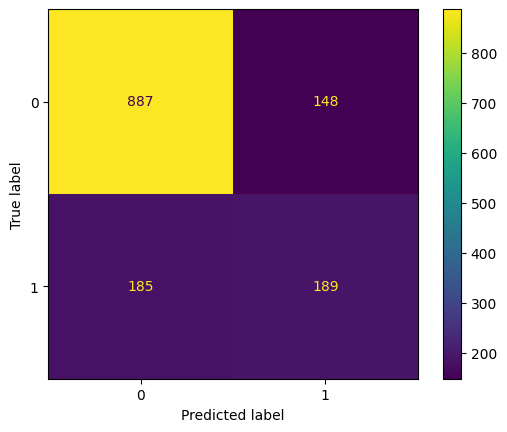

In [33]:
# Task 5 — Random Forest metrics + confusion matrix
accuracy = accuracy_score(y_test, y_test_pred_rf)
precision = precision_score(y_test, y_test_pred_rf)
recall = recall_score(y_test, y_test_pred_rf)
f1 = f1_score(y_test, y_test_pred_rf)

# Display results
print("Random Forest Metrics")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_rf)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

**Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy |76% |
| Precision | 56%|
| Recall | 50%|
| F1-score | 53%|

**Observation (confusion matrix):**
[[887 148]
 [185 189]]

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

**Task 6 — Comparison Table**

| Metric | Decision Tree | Random Forest |
|---|---|---|
| Accuracy |72% | 76%|
| Precision | 48%| 56%|
| Recall | 47%| 50%|
| F1-score | 48%| 53%|

**Answer 7:**
Random Forest combines many decision trees instead of relying on a single tree. Each tree is trained using different samples/features, and their predictions are combined. This reduces overfitting and makes the model more stable and better at generalizing to unseen test data.

---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [34]:
# Task 8 — 5-fold cross-validation for both models

# Decision Tree — 5-fold CV
dt_cv_scores = cross_val_score(
    dt,
    X,
    y,
    cv=5,
    scoring="f1"
)

# Random Forest — 5-fold CV
rf_cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="f1"
)

# Decision Tree results
print("Decision Tree CV F1-scores:", dt_cv_scores)
print("Decision Tree Mean F1:", dt_cv_scores.mean())
print("Decision Tree STD:", dt_cv_scores.std())

# Random Forest results
print("\nRandom Forest CV F1-scores:", rf_cv_scores)
print("Random Forest Mean F1:", rf_cv_scores.mean())
print("Random Forest STD:", rf_cv_scores.std())

Decision Tree CV F1-scores: [0.50847458 0.50592885 0.48831169 0.4869326  0.50134048]
Decision Tree Mean F1: 0.49819764012728773
Decision Tree STD: 0.00894312828794453

Random Forest CV F1-scores: [0.552822   0.52259887 0.50280899 0.5065123  0.55602837]
Random Forest Mean F1: 0.5281541051467074
Random Forest STD: 0.022481471104505747


**Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---|---|
| Decision Tree | 49%|8% |
| Random Forest | 52%| 22%|

**Answer 9:**
_(your answer here)_

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [35]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV
    # Small parameter grid
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run the search
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

**Answer 11 (best hyperparameters & CV score):**
_(your answer here)_

In [36]:
# Task 12 — evaluate the tuned model on the test set
# Get the best model from GridSearchCV
tuned_rf = grid_search.best_estimator_

# Predict on the held-out test set
y_test_pred_tuned = tuned_rf.predict(X_test)

# Calculate the four metrics
tuned_accuracy = accuracy_score(y_test, y_test_pred_tuned)
tuned_precision = precision_score(y_test, y_test_pred_tuned)
tuned_recall = recall_score(y_test, y_test_pred_tuned)
tuned_f1 = f1_score(y_test, y_test_pred_tuned)

# Display results
print("Tuned Random Forest Metrics")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)

Tuned Random Forest Metrics
Accuracy : 0.7913413768630234
Precision: 0.6351351351351351
Recall   : 0.5026737967914439
F1-score : 0.5611940298507463


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 79%|
| Precision | 63%|
| Recall | 50%|
| F1-score | 56%|

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy |72% | 72%| 79%|
| Precision | 48%| 56%| 63%|
| Recall | 47%| 50%| 50%|
| F1-score | 48%| 53%| 56%|

---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

Top 10 Features:
tenure                            0.197982
TotalCharges                      0.154104
MonthlyCharges                    0.117713
InternetService_Fiber optic       0.078895
Contract_Two year                 0.058855
PaymentMethod_Electronic check    0.052653
OnlineSecurity_Yes                0.041304
Contract_One year                 0.034187
TechSupport_Yes                   0.025158
PaperlessBilling_Yes              0.021302
dtype: float64


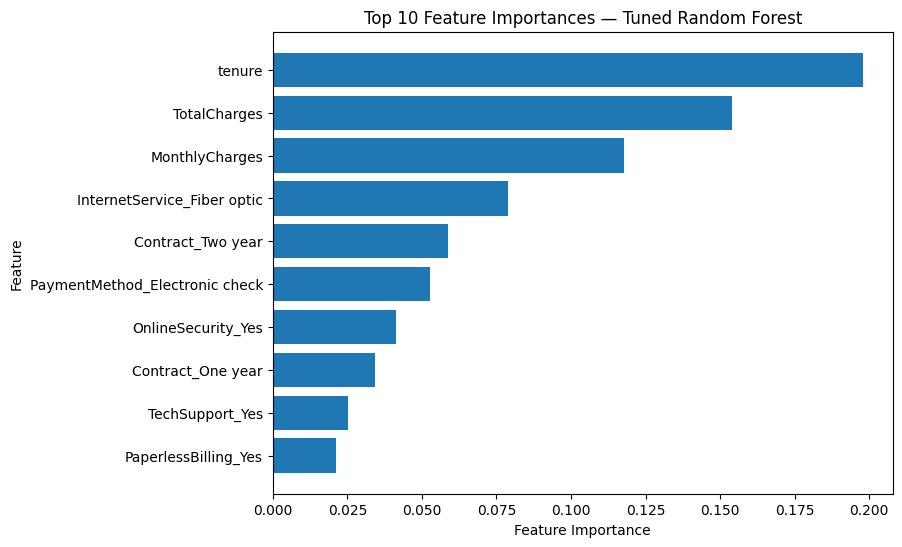

In [37]:
# Task 14 — extract and visualize feature importances

# Get feature importances from the tuned Random Forest
importances = tuned_rf.feature_importances_

# Create a Series with feature names
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

# Display the top 10 features
print("Top 10 Features:")
print(feature_importance.head(10))

# Plot top 10 features
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(top_features.index, top_features.values)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Tuned Random Forest")
plt.show()

**Answer 14:**
_(your answer here)_

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
_(your answer here)_

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [47]:
# Task 16 — Kaggle submission

# Read raw/original dataset
raw_df = pd.read_csv("Telco-Customer-Churn.csv")

# Get customer IDs using the same test-set indexes
customer_ids = raw_df.loc[X_test.index, "customerID"]

# Create submission
submission = pd.DataFrame({
    "customerID": customer_ids.values,
    "Churn": y_test_pred_tuned
})

# Save submission
submission.to_csv("submission.csv", index=False)

print(submission.head())
print("Submission shape:", submission.shape)
print(submission.columns.tolist())
print(submission.isnull().sum())

   customerID  Churn
0  4376-KFVRS      0
1  2754-SDJRD      1
2  9917-KWRBE      0
3  0365-GXEZS      0
4  9385-NXKDA      0
Submission shape: (1409, 2)
['customerID', 'Churn']
customerID    0
Churn         0
dtype: int64


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
_(your answer here)_

**Answer 18 — Next steps:**
_(your answer here)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted